# AP 155 Lab Exercise
---
## Exercise 7: Root Finding

_Instructions_: 
- **Report figure:** (See Problem) Plot the convergence of the values towards the root of $f(x)$. That is, plot $x_i$ vs. $i$ for each of the four methods ($x_i$ is the output of the method on the $i$th step). Overlay the convergence curves on a single plot and check the convergence. You may have more than four curves; for instance, you could have used newton's method twice for two different guesses. Make sure to label your curves (method + initial guesses).
- **Report discussion:**
    - Explain the report figure.
    - What are the advantages and disadvantages of the root-finding methods?
- **Code**: Complete the code and ensure it is functional, error-free, readable, and efficient (where needed). Include concise Markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Botron, Christan Jake
- _Student No._: 2024-10168
- _Section_: THU-TX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Report figure

<img src="root_plot.png" alt="Plot of all the roots">


<figcaption align="center"><b>Figure 1:</b> Convergence behavior of various numerical root-finding algorithms.</figcaption>

The plot demonstrates the computed root approximations ($x_n$) across successive iterations ($n$) for the Secant, Fixed-Point, Bisection, and Newton's methods evaluated under various initial guesses. The horizontal dashed red lines denote the locations of the true roots of the function at approximately -1.193, 2.000, and 4.596.

### Report discussion

From Figure 1, Newton's method demonstrates the fastest convergence to all three roots. However, its primary disadvantage is the strict requirement of an analytically computable derivative. The bisection method provides guaranteed, stable convergence to the outer roots at $-1.193$ and $4.596$, but has a slower convergence rate and a complete inability to detect the root at $2.000$ due to the lack of a sign change across the axis. The secant method bypasses the derivative requirement but is highly susceptible to severe initial oscillations, as evident in the $[-1.3, 0]$ trial before it finally settles. Finally, the fixed-point method is straightforward to program but is very slow and inefficient, as seen in the gradual convergence toward the $2.000$ root. The fixed-point function $g_2(x)$ only converges to the root at $x=2.000$ because this is the only location where the mathematical stability criterion $\vert{}g_2'(x)\vert{} < 1$ is satisfied. At the other roots, the steep slope of the original function causes $\vert{}g_2'(x)\vert{}$ to significantly exceed $1$, actively forcing the iterative sequence to diverge.

### Other comments


---
## Section 2: Code

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import math

### Problem 1: Root Finding


Implement root finders *manually* to find the roots of an arbitrary function

1. fixed-point method (relaxation, needs an initial guess)
2. bisection method (bracketing, needs two bounds)
3. newton's method (known derivative, needs an initial guess)
4. secant method (approximate derivative, needs two initial guesses)

Consider the function

$$
f(x) = -x^5 + 4x^4 - 4x^3 + x^2 e^x - 2x^2 -4xe^x + 8x + 4e^x -8
$$

5. Plot the function from x=-2 to x=-5. You may want to "enlarge" the plot by rescaling/"cropping" the y-axis. You should be able to estimate where the roots are approximately
   
6. Find the roots of $f(x)$ by implementing the four methods shown.

7. Report Figure: Plot the convergence of the values towards the root of $f(x)$. That is, plot $x_i$ vs. $i$ for each of the four methods ($x_i$ is the output of the method on the $i$th step). Overlay the convergence curves on a single plot and check the convergence. You may have more than four curves; for instance, you could have used newton's method twice for two different guesses. Make sure to label your curves (method + initial guesses).

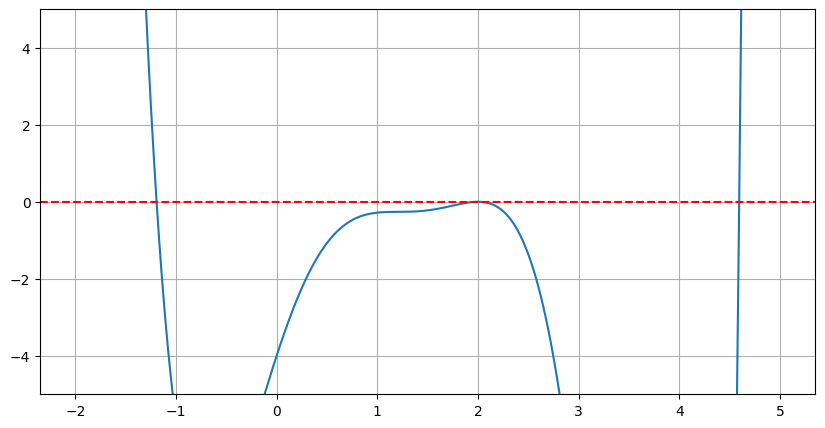

In [26]:
def f(x):
    return -x**5 + 4*x**4 - 4*x**3 + (x**2)*np.exp(x) - 2*x**2 - 4*x*np.exp(x) + 8*x + 4*np.exp(x) - 8
def f_prime(x):
    return -5*x**4 + 16*x**3 - 12*x**2 + (x**2 * np.exp(x) + np.exp(x)*2*x) - 4*x - 4*(x*np.exp(x) + np.exp(x)) + 8 + 4*np.exp(x)
def g(x):
    return (-x**5 + 4*x**4 - 4*x**3 + (x**2)*np.exp(x) - 2*x**2 - 4*x*np.exp(x) + 4*np.exp(x) - 8) / (-8)
    

x_vals = np.linspace(-2, 5, 1000)
y_vals = f(x_vals)


plt.figure(figsize=(10, 5))
plt.ylim(-5, 5)
plt.plot(x_vals, y_vals, label="f(x)")
plt.grid(True) 
plt.axhline(y=0, linestyle="--", color='red')
plt.show()

In [58]:
#note: I removed the tolerance so I can see whether the algorithm messes up after a few more (a few hundred) iterations even after its perceived convergence to a root


#fixed-point method
def fixed_point_method(x0, iterations=200):
    x_n_list = [x0]
    x = x0
    i = 0
    
    while i <= iterations:
        x_n = g(x)                #x1 = g(x0)
        x_n_list.append(x_n)
        x = x_n                   #we then set x0 = x1, and we can do x2 = g(x1) for our next iteration and so on (the difference between 'x_n's should converge into our root)
        i += 1
    return x_n_list

#bisection method
def bisection_method(x1,x2, iterations=200):
    x_n_list = []
    i = 0
        
    while i <= iterations:
        x3 = (x1 + x2) / 2.0         #x1 and x2 are initial guess bounds
        x_n_list.append(x3)
        if f(x3) * f(x1) < 0:#if this is true, then the root must be between [x1,x3] so we use them as reference for the next iteration (ref: https://www.geeksforgeeks.org/dsa/program-for-bisection-method/)
            x2 = x3
        else: #else, it must mean that it is outside the[x1,x3] bound so we use [x2,x3]  as our new bounds
            x1 = x3
        i += 1
    return x_n_list

#newton's method
def newtons_method(x0, iterations=200):
    x_n_list = [x0]
    x = x0                          #initial guess
    i = 0

    while i <= iterations:
        if f_prime(x) == 0: #stop division by zero
            break
        x = x - (f(x) / f_prime(x)) #refer to notes (board discussion)
        x_n_list.append(x)
        i += 1
    return x_n_list

#secant method
def secant_method(x1, x2, iterations=200):
    x_n_list = [x1, x2]
    i = 0
    
    while i <= iterations:
        denom = f(x2) - f(x1)        
        if denom == 0: #stop division by zero
            break
        x3 = x2 - ( f(x2) * (x2 - x1) / denom )
        x_n_list.append(x3)
        x1, x2 = x2, x3
        i += 1
    return x_n_list
        

In [53]:
#guesses
fp_middle_guess = -1
bisection1_guess = [4,5]
bisection2_guess = [-2,-1]

newton1_guess = -1
newton2_guess = 2.2
newton3_guess = 4.5

secant1_guess = [-1.3, 0]
secant2_guess = [1,2]
secant3_guess = [3,5]

#root finding
fp_middle = fixed_point_method(fp_middle_guess)
bisection1 = bisection_method(bisection1_guess[0], bisection1_guess[1])
bisection2 = bisection_method(bisection2_guess[0],bisection2_guess[1])

newton1 = newtons_method(newton1_guess)
newton2 = newtons_method(newton2_guess)
newton3 = newtons_method(newton3_guess)

secant1 = secant_method(secant1_guess[0], secant1_guess[1])
secant2 = secant_method(secant2_guess[0], secant2_guess[1])
secant3 = secant_method(secant3_guess[0], secant3_guess[1])

#roots for y-axis label
roots = [-1.19269, 2.0, 4.59586]
standard_ticks = [-2, 0, 4, 6]

Text(0.5, 1.0, 'Root Finding using Fixed-Point Method and Bisection Method')

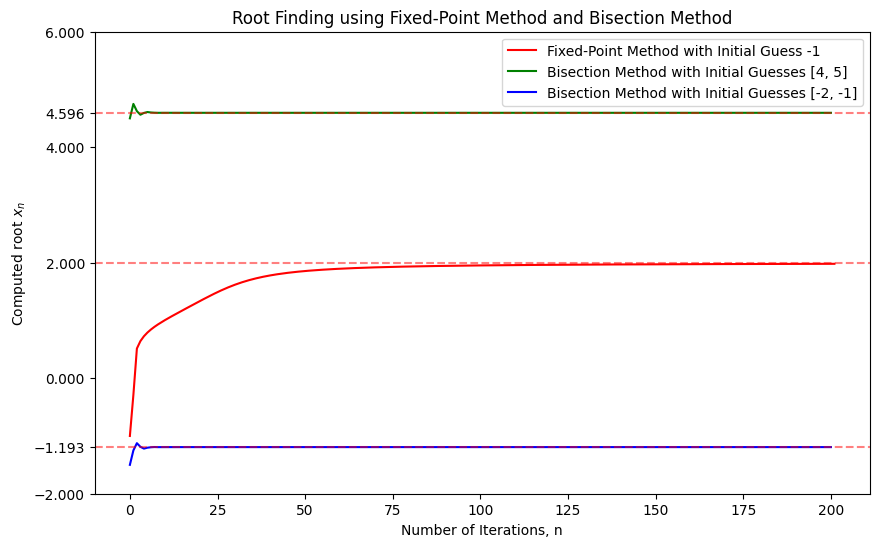

In [54]:
#individual plotting (fixed point + bisection)
plt.figure(figsize=(10, 6))
plt.plot(fp_middle, label=f"Fixed-Point Method with Initial Guess {fp_middle_guess}", color='r')
plt.plot(bisection1, label=f"Bisection Method with Initial Guesses {bisection1_guess}", color='g')
plt.plot(bisection2, label=f"Bisection Method with Initial Guesses {bisection2_guess}", color='b')
plt.ylim(-2,6)
plt.legend()
plt.axhline(y=2, linestyle="--", color='red', alpha=0.5)
plt.axhline(y=4.59586, linestyle="--", color='red', alpha=0.5)
plt.axhline(y=-1.19269, linestyle="--", color='red', alpha=0.5)
plt.xlabel("Number of Iterations, n")
plt.ylabel(f"Computed root $x_n$")
plt.yticks(standard_ticks + roots)
plt.title("Root Finding using Fixed-Point Method and Bisection Method")

Text(0.5, 1.0, "Root Finding using Newton's Method")

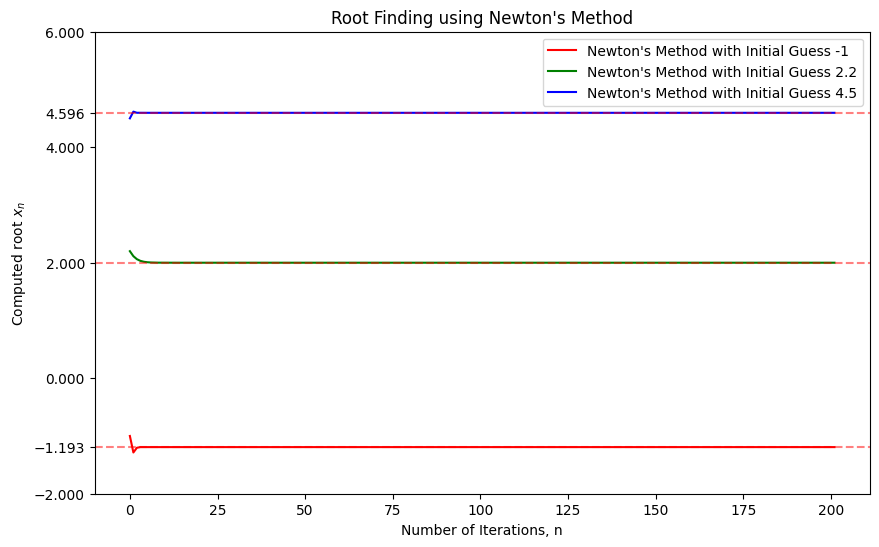

In [55]:
#individual plotting (newton)
plt.figure(figsize=(10, 6))
plt.plot(newton1, label=f"Newton's Method with Initial Guess {newton1_guess}", color='r')
plt.plot(newton2, label=f"Newton's Method with Initial Guess {newton2_guess}", color='g')
plt.plot(newton3, label=f"Newton's Method with Initial Guess {newton3_guess}", color='b')
plt.ylim(-2, 6)
plt.legend()
plt.axhline(y=2, linestyle="--", color='red', alpha=0.5)
plt.axhline(y=4.59586, linestyle="--", color='red', alpha=0.5)
plt.axhline(y=-1.19269, linestyle="--", color='red', alpha=0.5)
plt.xlabel("Number of Iterations, n")
plt.ylabel(f"Computed root $x_n$")
plt.yticks(standard_ticks + roots)
plt.title("Root Finding using Newton's Method")

Text(0.5, 1.0, 'Root Finding using Secant Method')

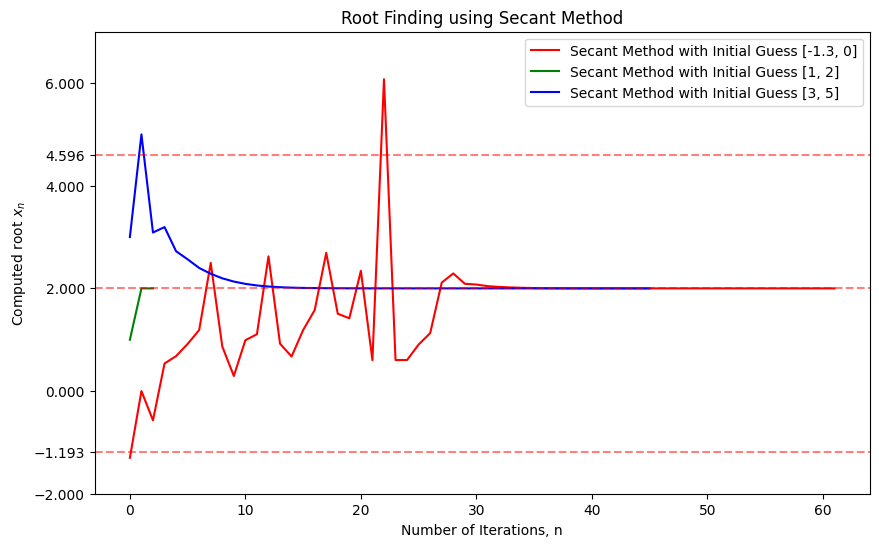

In [56]:
#individual plotting (secant)
plt.figure(figsize=(10, 6))
plt.plot(secant1, label=f"Secant Method with Initial Guess {secant1_guess}" , color="r")
plt.plot(secant2, label=f"Secant Method with Initial Guess {secant2_guess}", color="g")
plt.plot(secant3, label=f"Secant Method with Initial Guess {secant3_guess}", color="b")
plt.ylim(-2, 7)
plt.legend()
plt.axhline(y=2, linestyle="--", color='red', alpha=0.5)
plt.axhline(y=4.59586, linestyle="--", color='red', alpha=0.5)
plt.axhline(y=-1.19269, linestyle="--", color='red', alpha=0.5)
plt.xlabel("Number of Iterations, n")
plt.ylabel(f"Computed root $x_n$")
plt.yticks(standard_ticks + roots)
plt.title("Root Finding using Secant Method")

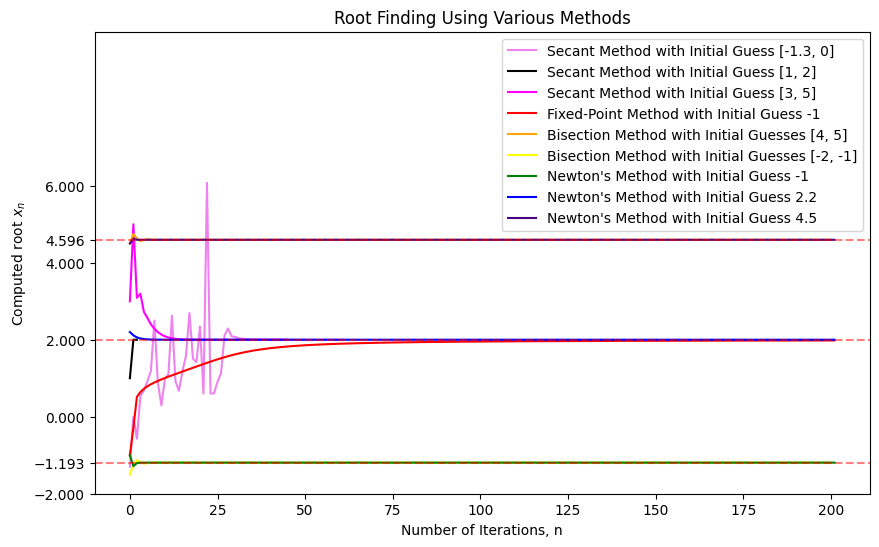

In [57]:
plt.figure(figsize=(10, 6))
plt.plot(secant1, label=f"Secant Method with Initial Guess {secant1_guess}" , color="violet")
plt.plot(secant2, label=f"Secant Method with Initial Guess {secant2_guess}", color="black")
plt.plot(secant3, label=f"Secant Method with Initial Guess {secant3_guess}", color="magenta")
plt.plot(fp_middle, label=f"Fixed-Point Method with Initial Guess {fp_middle_guess}", color='red')
plt.plot(bisection1, label=f"Bisection Method with Initial Guesses {bisection1_guess}", color='orange')
plt.plot(bisection2, label=f"Bisection Method with Initial Guesses {bisection2_guess}", color='yellow')
plt.plot(newton1, label=f"Newton's Method with Initial Guess {newton1_guess}", color='green')
plt.plot(newton2, label=f"Newton's Method with Initial Guess {newton2_guess}", color='blue')
plt.plot(newton3, label=f"Newton's Method with Initial Guess {newton3_guess}", color='indigo')
plt.ylim(-2, 10)
plt.legend()
plt.axhline(y=2, linestyle="--", color='red', alpha=0.5)
plt.axhline(y=4.59586, linestyle="--", color='red', alpha=0.5)
plt.axhline(y=-1.19269, linestyle="--", color='red', alpha=0.5)
plt.xlabel("Number of Iterations, n")
plt.ylabel(f"Computed root $x_n$")
plt.yticks(standard_ticks + roots)
plt.title("Root Finding Using Various Methods")
plt.savefig("root_plot.png", bbox_inches="tight", dpi=300)
plt.show()

#### Problem 1 code summary

Four numerical root-finding algorithms (i.e., Fixed-Point, Bisection, Newton's, and Secant) were implemented to approximate the roots of the given function. Each function stores and returns the full history of computed approximations (x_n_list) to visualize the efficiency of the algorithms. Do note, though, that early stopping tolerances were intentionally omitted to force 200 iterations. While computationally inefficient, this was done for demonstration purposes to observe whether the algorithms remain stable or exhibit instability after the perceived convergence. I also added lines of code to stop division by zero for the Newton and Secant methods to prevent errors runtime errors.

---